In [6]:
import numpy as np
import matplotlib.pyplot as plt
import os
print(" Done")

 Done


In [7]:
X_train = X_test = Y_train = Y_test = None

# ── METHOD 1: Load local file if already downloaded ────────────
if os.path.exists('mnist.npz'):
    print("Found mnist.npz locally, loading...")
    d = np.load('mnist.npz')
    X_train = d['x_train'].reshape(-1, 784) / 255.0
    Y_train = d['y_train']
    X_test  = d['x_test'].reshape(-1, 784)  / 255.0
    Y_test  = d['y_test']
    print("Loaded from local file")

Found mnist.npz locally, loading...
Loaded from local file


In [8]:
def one_hot(y, num_classes=10):
    oh = np.zeros((len(y), num_classes))
    oh[np.arange(len(y)), y] = 1
    return oh

Y_train_oh = one_hot(Y_train)
Y_test_oh  = one_hot(Y_test)

print(f"Y_train_oh : {Y_train_oh.shape}")
print(f"Y_test_oh  : {Y_test_oh.shape}")
print(f"Example — label {Y_train[0]} → {Y_train_oh[0]}")
print("One-hot encoding done")

Y_train_oh : (60000, 10)
Y_test_oh  : (10000, 10)
Example — label 5 → [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
One-hot encoding done


In [9]:
np.random.seed(42)

W1 = np.random.uniform(-0.5, 0.5, (784, 128))
b1 = np.zeros((1, 128))

W2 = np.random.uniform(-0.5, 0.5, (128, 64))
b2 = np.zeros((1, 64))

W3 = np.random.uniform(-0.5, 0.5, (64, 10))
b3 = np.zeros((1, 10))

total = W1.size + b1.size + W2.size + b2.size + W3.size + b3.size
print("Weights initialised with seed 42")
print(f"W1:{W1.shape}  W2:{W2.shape}  W3:{W3.shape}")
print(f"Total parameters: {total:,}")
print("Weights ready")

Weights initialised with seed 42
W1:(784, 128)  W2:(128, 64)  W3:(64, 10)
Total parameters: 109,386
Weights ready


In [10]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))

def sigmoid_derivative(a):
    return a * (1.0 - a)

# Quick test
print("sigmoid(0)   =", sigmoid(0.0))        # must be 0.5
print("sigmoid'(0.5)=", sigmoid_derivative(0.5))  # must be 0.25
print("Activation functions ready")

sigmoid(0)   = 0.5
sigmoid'(0.5)= 0.25
Activation functions ready


In [11]:
def forward_pass(X, W1, b1, W2, b2, W3, b3):
    Z1 = X @ W1 + b1
    A1 = sigmoid(Z1)

    Z2 = A1 @ W2 + b2
    A2 = sigmoid(Z2)

    Z3 = A2 @ W3 + b3
    A3 = sigmoid(Z3)

    return Z1, A1, Z2, A2, Z3, A3

print("forward_pass() ready")

forward_pass() ready


In [12]:
def mse_loss(Y_true, Y_pred):
    return float(np.mean((Y_true - Y_pred) ** 2))

print("mse_loss() ready")

mse_loss() ready


In [13]:
def backpropagation(X, Y_true, Z1, A1, Z2, A2, Z3, A3, W1, W2, W3):
    m = X.shape[0]

    # Output layer delta
    delta3 = -2.0 * (Y_true - A3) * sigmoid_derivative(A3)
    dW3 = (A2.T @ delta3) / m
    db3 = np.mean(delta3, axis=0, keepdims=True)

    # Hidden layer 2 delta
    delta2 = (delta3 @ W3.T) * sigmoid_derivative(A2)
    dW2 = (A1.T @ delta2) / m
    db2 = np.mean(delta2, axis=0, keepdims=True)

    # Hidden layer 1 delta
    delta1 = (delta2 @ W2.T) * sigmoid_derivative(A1)
    dW1 = (X.T @ delta1) / m
    db1 = np.mean(delta1, axis=0, keepdims=True)

    return dW1, db1, dW2, db2, dW3, db3

print("backpropagation() ready")

backpropagation() ready


In [14]:
def update_weights(W1, b1, W2, b2, W3, b3,
                   dW1, db1, dW2, db2, dW3, db3,
                   lr):
    W1 -= lr * dW1;  b1 -= lr * db1
    W2 -= lr * dW2;  b2 -= lr * db2
    W3 -= lr * dW3;  b3 -= lr * db3
    return W1, b1, W2, b2, W3, b3

print(" update_weights() ready")

 update_weights() ready


In [15]:
LEARNING_RATE = 0.1
EPOCHS        = 20
BATCH_SIZE    = 32
loss_history  = []

print(f"Starting training: {EPOCHS} epochs, batch={BATCH_SIZE}, lr={LEARNING_RATE}")
print("-" * 55)

for epoch in range(EPOCHS):

    # Shuffle each epoch
    idx    = np.random.permutation(X_train.shape[0])
    X_shuf = X_train[idx]
    Y_shuf = Y_train_oh[idx]

    # Mini-batch loop
    for start in range(0, X_train.shape[0], BATCH_SIZE):
        Xb = X_shuf[start : start + BATCH_SIZE]
        Yb = Y_shuf[start : start + BATCH_SIZE]

        Z1,A1,Z2,A2,Z3,A3 = forward_pass(Xb, W1,b1,W2,b2,W3,b3)

        dW1,db1,dW2,db2,dW3,db3 = backpropagation(
            Xb, Yb, Z1,A1,Z2,A2,Z3,A3, W1,W2,W3)

        W1,b1,W2,b2,W3,b3 = update_weights(
            W1,b1,W2,b2,W3,b3,
            dW1,db1,dW2,db2,dW3,db3,
            LEARNING_RATE)

    # Record epoch loss
    _,_,_,_,_,A3_full = forward_pass(X_train, W1,b1,W2,b2,W3,b3)
    loss = mse_loss(Y_train_oh, A3_full)
    loss_history.append(loss)
    print(f"Epoch {epoch+1:>2}/{EPOCHS}  |  Loss: {loss:.6f}")

print("-" * 55)
print("Training complete!")

Starting training: 20 epochs, batch=32, lr=0.1
-------------------------------------------------------
Epoch  1/20  |  Loss: 0.029573
Epoch  2/20  |  Loss: 0.020783
Epoch  3/20  |  Loss: 0.017234
Epoch  4/20  |  Loss: 0.015297
Epoch  5/20  |  Loss: 0.013814
Epoch  6/20  |  Loss: 0.012714
Epoch  7/20  |  Loss: 0.011880
Epoch  8/20  |  Loss: 0.011142
Epoch  9/20  |  Loss: 0.010536
Epoch 10/20  |  Loss: 0.010015
Epoch 11/20  |  Loss: 0.009536
Epoch 12/20  |  Loss: 0.009125
Epoch 13/20  |  Loss: 0.008790
Epoch 14/20  |  Loss: 0.008410
Epoch 15/20  |  Loss: 0.008107
Epoch 16/20  |  Loss: 0.007827
Epoch 17/20  |  Loss: 0.007642
Epoch 18/20  |  Loss: 0.007317
Epoch 19/20  |  Loss: 0.007136
Epoch 20/20  |  Loss: 0.006887
-------------------------------------------------------
Training complete!


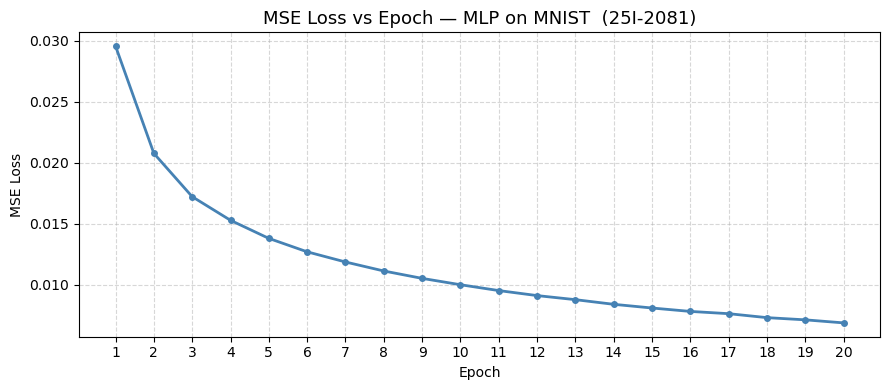

Initial loss : 0.029573
Final loss   : 0.006887
Loss curve saved as loss_curve.png


In [16]:
plt.figure(figsize=(9, 4))
plt.plot(range(1, EPOCHS+1), loss_history,
         marker='o', markersize=4,
         color='steelblue', linewidth=2)
plt.title('MSE Loss vs Epoch — MLP on MNIST  (25I-2081)', fontsize=13)
plt.xlabel('Epoch');  plt.ylabel('MSE Loss')
plt.xticks(range(1, EPOCHS+1))
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('loss_curve.png', dpi=150)
plt.show()

print(f"Initial loss : {loss_history[0]:.6f}")
print(f"Final loss   : {loss_history[-1]:.6f}")
print("Loss curve saved as loss_curve.png")

In [17]:
_,_,_,_,_,A3_test = forward_pass(X_test, W1,b1,W2,b2,W3,b3)
predictions = np.argmax(A3_test, axis=1)

correct  = np.sum(predictions == Y_test)
accuracy = correct / len(Y_test) * 100.0

print("=" * 40)
print(f"  Test Accuracy : {accuracy:.2f}%")
print(f"  Correct       : {correct} / {len(Y_test)}")
print("=" * 40)

# Per-class breakdown
print("\nPer-class accuracy:")
for cls in range(10):
    mask    = Y_test == cls
    cls_acc = np.mean(predictions[mask] == Y_test[mask]) * 100
    bar     = "█" * int(cls_acc // 5)
    print(f"  Digit {cls}: {cls_acc:5.1f}%  {bar}")

  Test Accuracy : 95.54%
  Correct       : 9554 / 10000

Per-class accuracy:
  Digit 0:  98.9%  ███████████████████
  Digit 1:  98.7%  ███████████████████
  Digit 2:  95.0%  ██████████████████
  Digit 3:  95.2%  ███████████████████
  Digit 4:  94.7%  ██████████████████
  Digit 5:  93.5%  ██████████████████
  Digit 6:  96.2%  ███████████████████
  Digit 7:  94.3%  ██████████████████
  Digit 8:  95.1%  ███████████████████
  Digit 9:  93.4%  ██████████████████


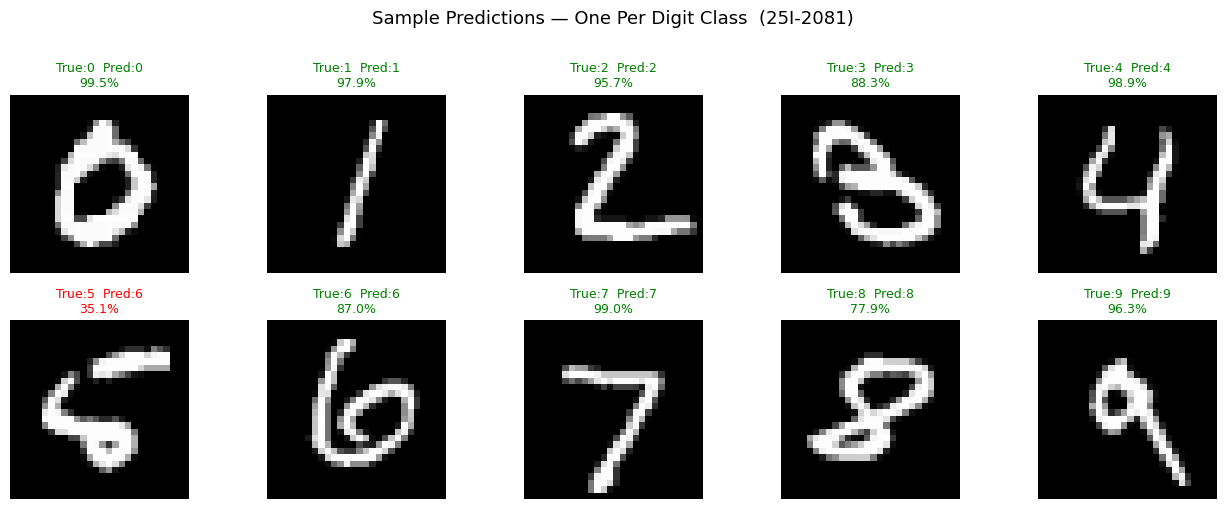

Sample predictions saved as sample_predictions.png


In [18]:
fig, axes = plt.subplots(2, 5, figsize=(13, 5))
fig.suptitle('Sample Predictions — One Per Digit Class  (25I-2081)',
             fontsize=13, y=1.01)

# Find one example per digit class 0-9
shown = {}
for i in range(len(X_test)):
    lbl = int(Y_test[i])
    if lbl not in shown:
        shown[lbl] = i
    if len(shown) == 10:
        break

for ax, digit in zip(axes.flat, range(10)):
    idx  = shown[digit]
    true = int(Y_test[idx])
    pred = int(predictions[idx])
    conf = float(A3_test[idx, pred]) * 100

    ax.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    ax.axis('off')
    color = 'green' if pred == true else 'red'
    ax.set_title(f'True:{true}  Pred:{pred}\n{conf:.1f}%',
                 fontsize=9, color=color)

plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Sample predictions saved as sample_predictions.png")

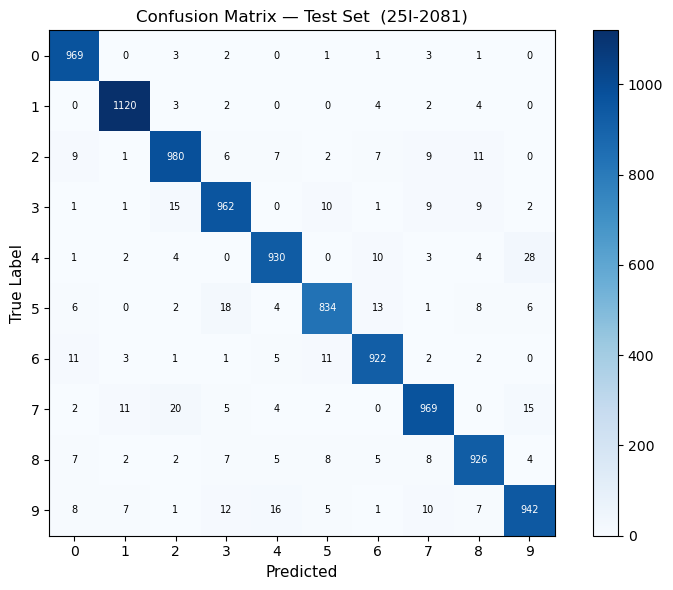

Confusion matrix saved as confusion_matrix.png


In [19]:
conf_mat = np.zeros((10, 10), dtype=int)
for t, p in zip(Y_test, predictions):
    conf_mat[t, p] += 1

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(conf_mat, cmap='Blues')
plt.colorbar(im, ax=ax)
ax.set_xticks(range(10));  ax.set_yticks(range(10))
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)
ax.set_title('Confusion Matrix — Test Set  (25I-2081)', fontsize=12)

for i in range(10):
    for j in range(10):
        v = conf_mat[i, j]
        c = 'white' if v > conf_mat.max()*0.5 else 'black'
        ax.text(j, i, str(v), ha='center', va='center', fontsize=7, color=c)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("Confusion matrix saved as confusion_matrix.png")

In [20]:
print("=" * 50)
print("     MVC PROJECT — TASK 7 FINAL SUMMARY")
print("     Roll No : 25I-2081")
print("=" * 50)
print(f"  Architecture   :  784 → 128 → 64 → 10")
print(f"  Activation     :  Sigmoid")
print(f"  Loss Function  :  MSE")
print(f"  Optimizer      :  Mini-Batch Gradient Descent")
print(f"  Learning Rate  :  {LEARNING_RATE}")
print(f"  Batch Size     :  {BATCH_SIZE}")
print(f"  Epochs         :  {EPOCHS}")
print(f"  Initial Loss   :  {loss_history[0]:.6f}")
print(f"  Final Loss     :  {loss_history[-1]:.6f}")
print(f"  Test Accuracy  :  {accuracy:.2f}%")
print("=" * 50)
print("  Outputs generated:")
print("    [1] loss_curve.png")
print("    [2] Test accuracy printed above")
print("    [3] sample_predictions.png")
print("    [4] confusion_matrix.png")
print("=" * 50)

     MVC PROJECT — TASK 7 FINAL SUMMARY
     Roll No : 25I-2081
  Architecture   :  784 → 128 → 64 → 10
  Activation     :  Sigmoid
  Loss Function  :  MSE
  Optimizer      :  Mini-Batch Gradient Descent
  Learning Rate  :  0.1
  Batch Size     :  32
  Epochs         :  20
  Initial Loss   :  0.029573
  Final Loss     :  0.006887
  Test Accuracy  :  95.54%
  Outputs generated:
    [1] loss_curve.png
    [2] Test accuracy printed above
    [3] sample_predictions.png
    [4] confusion_matrix.png
